In [5]:
from sklearn.datasets import make_classification
import numpy as np
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,
                       n_classes=2,n_clusters_per_class=1,random_state=22,hypercube=False,class_sep=20)

In [7]:
import matplotlib.pyplot as plt


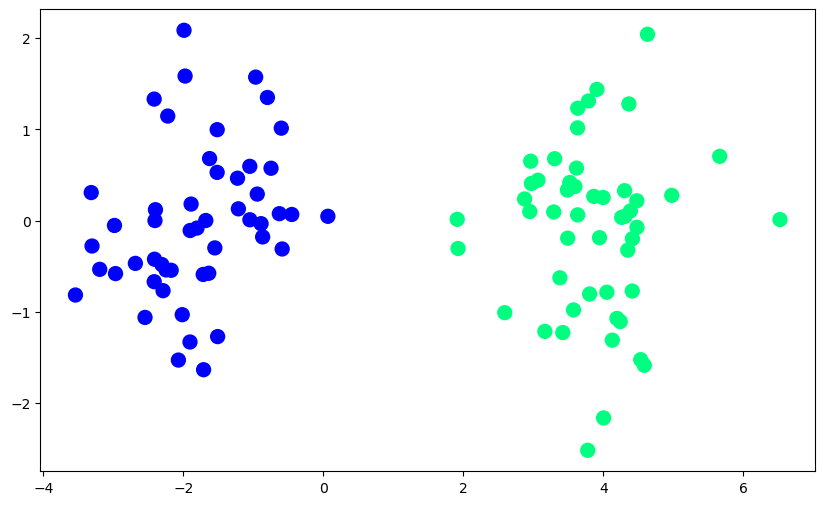

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [15]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(penalty=None,solver='sag')
lr.fit(X,y)

C:\Users\sanke\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [17]:
print(lr.coef_)
print(lr.intercept_)

[[ 3.99923765 -0.3895    ]]
[-2.89541993]


In [19]:
m1=-(lr.coef_[0][0]/lr.coef_[0][1])
b1=-(lr.intercept_/lr.coef_[0][1])

In [21]:

x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [229]:
def gd(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr_rate=0.8
    
    for i in range(5000):
        y_hat=sigmoid(np.dot(X,weights))
        weights=weights+lr_rate*(np.dot((y-y_hat),X)/X.shape[0])
    return weights[1:],weights[0]

In [231]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [233]:
coef_,intercept_=gd(X,y)

In [235]:
m=-coef_[0]/coef_[1]
b=-(intercept_/coef_[1])

In [237]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

(-3.0, 2.0)

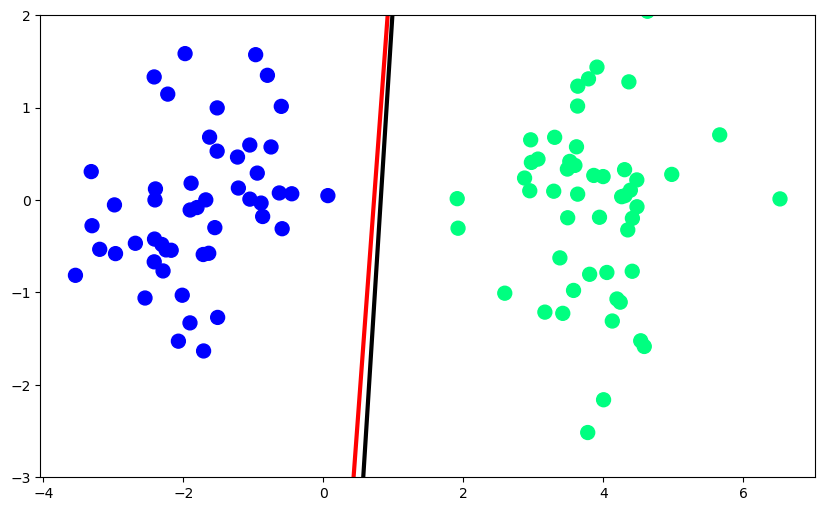

In [239]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3) # logistic line
plt.plot(x_input1,y_input1,color='black',linewidth=3) # our own  created line
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
